# Modeling - Homophily

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
from baseline_utils import fit_degroot_adjacency_scalar, degroot_rollout_prediction, evaluate_validation_model
from opinion_fitting import fit_homophily, rollout_with_homophily
from plot_utils import (
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
)

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 150,
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Cleaned data: /Users/samuelli/Documents/code/llm/llm-network/modeling/cleaned_data
Runs found: 67
  run_20260320-130058
  run_20260320-133304
  run_20260320-140500
  run_20260320-143643
  run_20260320-150827
  run_20260320-154019
  run_20260320-161210
  run_20260320-164400
  run_20260320-171544
  run_20260320-174722
  run_20260321-121900
  run_20260321-125108
  run_20260321-132251
  run_20260321-135440
  run_20260321-142622
  run_20260321-145803
  run_20260321-152938
  run_20260321-160106
  run_20260321-163235
  run_20260321-170416
  run_20260322-212540
  run_20260324-095805
  run_20260324-115915
  run_20260324-135956
  run_20260324-160041
  run_20260326-014533


## Data Construction

- Each run is mapped to a shared global agent index.
- Trajectories are built from the run data with the same preprocessing used in the baseline notebook.
- Neighbor sets are preserved per run for the homophily kernel.

In [2]:
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f'{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}')

Global agent count: 30
Global init priors available: 30
run_20260320-130058: trajectory shape=(9, 30), horizon=8
run_20260320-133304: trajectory shape=(12, 30), horizon=11
run_20260320-140500: trajectory shape=(9, 30), horizon=8
run_20260320-143643: trajectory shape=(9, 30), horizon=8
run_20260320-150827: trajectory shape=(9, 30), horizon=8
run_20260320-154019: trajectory shape=(11, 30), horizon=10
run_20260320-161210: trajectory shape=(9, 30), horizon=8
run_20260320-164400: trajectory shape=(11, 30), horizon=10
run_20260320-171544: trajectory shape=(9, 30), horizon=8
run_20260320-174722: trajectory shape=(10, 30), horizon=9
run_20260321-121900: trajectory shape=(11, 30), horizon=10
run_20260321-125108: trajectory shape=(10, 30), horizon=9
run_20260321-132251: trajectory shape=(8, 30), horizon=7
run_20260321-135440: trajectory shape=(12, 30), horizon=11
run_20260321-142622: trajectory shape=(10, 30), horizon=9
run_20260321-145803: trajectory shape=(10, 30), horizon=9
run_20260321-15293

In [8]:
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")

RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260320-130058: post_mean=0.256, post_min=0.100, post_max=0.367, slices=9
run_20260320-133304: post_mean=0.244, post_min=0.167, post_max=0.367, slices=12
run_20260320-140500: post_mean=0.341, post_min=0.233, post_max=0.433, slices=9
run_20260320-143643: post_mean=0.267, post_min=0.100, post_max=0.367, slices=9
run_20260320-150827: post_mean=0.289, post_min=0.233, post_max=0.367, slices=9
run_20260320-154019: post_mean=0.267, post_min=0.100, post_max=0.400, slices=11
run_20260320-161210: post_mean=0.278, post_min=0.133, post_max=0.367, slices=9
run_20260320-164400: post_mean=0.255, post_min=0.067, post_max=0.433, slices=11
run_20260320-171544: post_mean=0.326, post_min=0.233, post_max=0.400, slices=9
run_20260320-174722: post_mean=0.253, post_min=0.133, post_max=0.367, slices=10
run_20260321-121900: post_mean=0.248, post_min=0.200, post_max=0.333, slices=11
run_20260321-125108: post_mean=0.290, post_min=

## Homophily

In [3]:
HOMOPHILY = fit_homophily(RUN_TRAJ, RUN_NEIGHBORS, gamma0=1.0)
HOMOPHILY_A = HOMOPHILY['Abar']
HOMOPHILY_GAMMA = HOMOPHILY['gamma']

print('Homophily fit')
print('gamma:', HOMOPHILY_GAMMA)
print('Global pooled MSE loss:', HOMOPHILY['mse_pool'])
print('Status:', HOMOPHILY['status'])
print('Success:', HOMOPHILY['success'])

Homophily fit
gamma: 12.07499793826636
Global pooled MSE loss: 0.01589624770878232
Status: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Success: True


DeGroot adjacency gamma: 0.29378838899890913
Training metric horizon (shared): 5


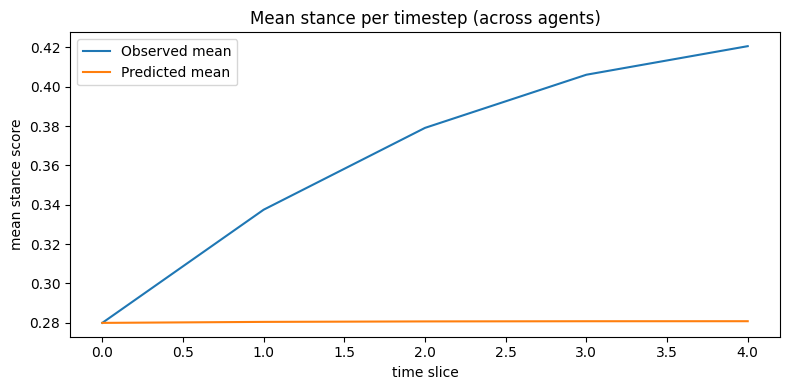

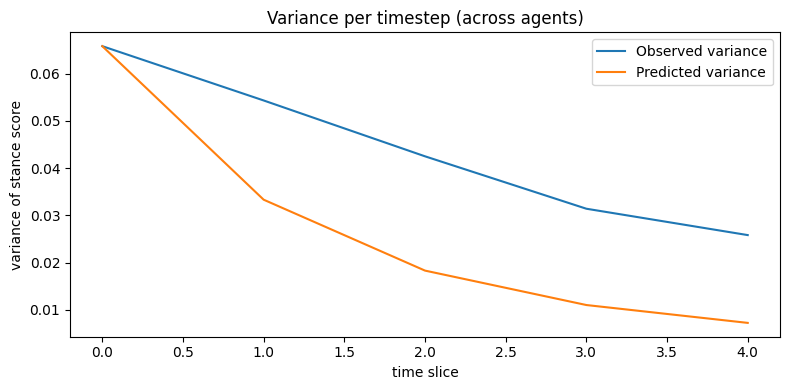

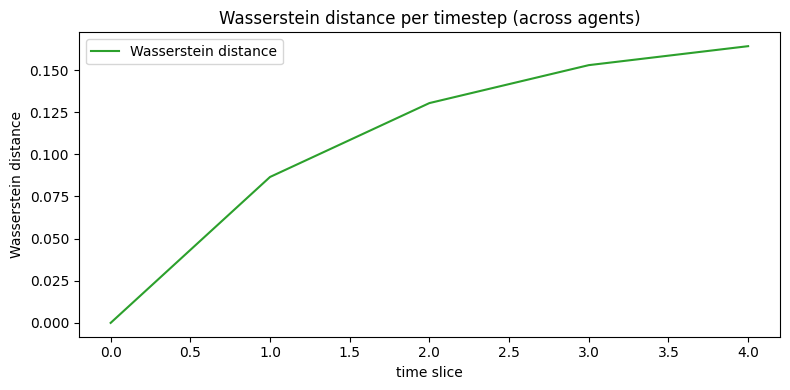

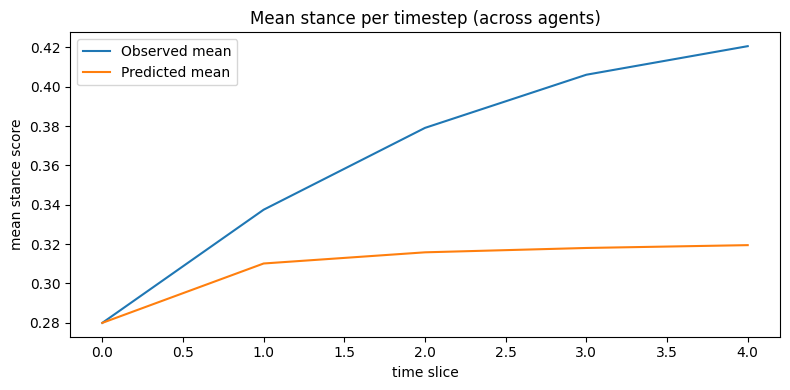

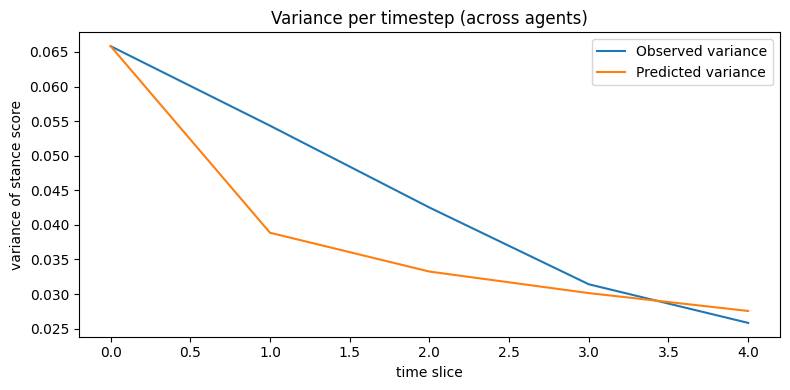

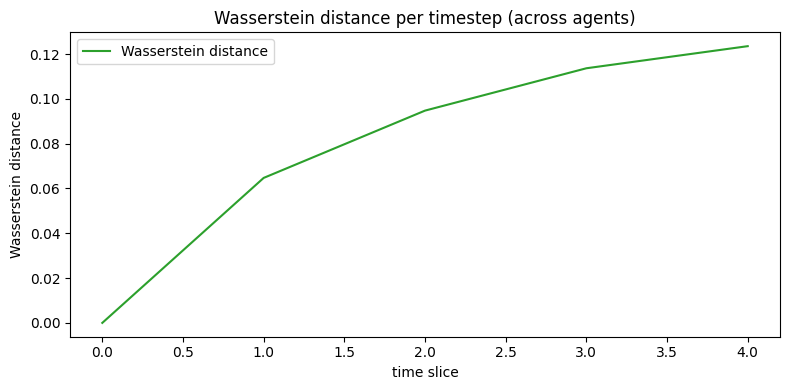

                      model  pooled_mse  transition_mse_mean  \
0  degroot_adjacency_scalar    0.012080             0.039759   
1                 homophily    0.015896             0.045073   

   mean_curve_abs_error  var_curve_abs_error  wasserstein_curve_mean  
0              0.084321             0.017300                0.106829  
1              0.061056             0.012238                0.079338  


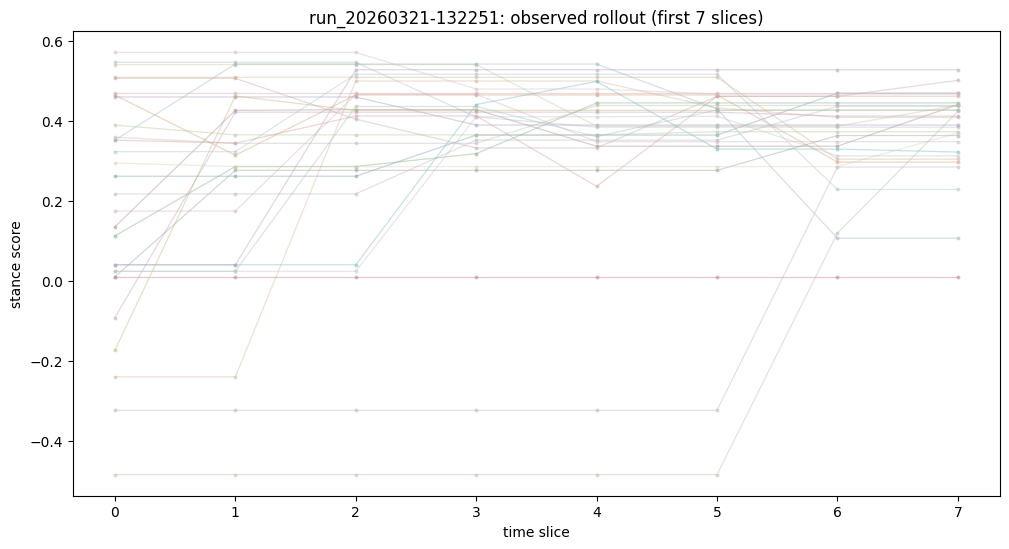

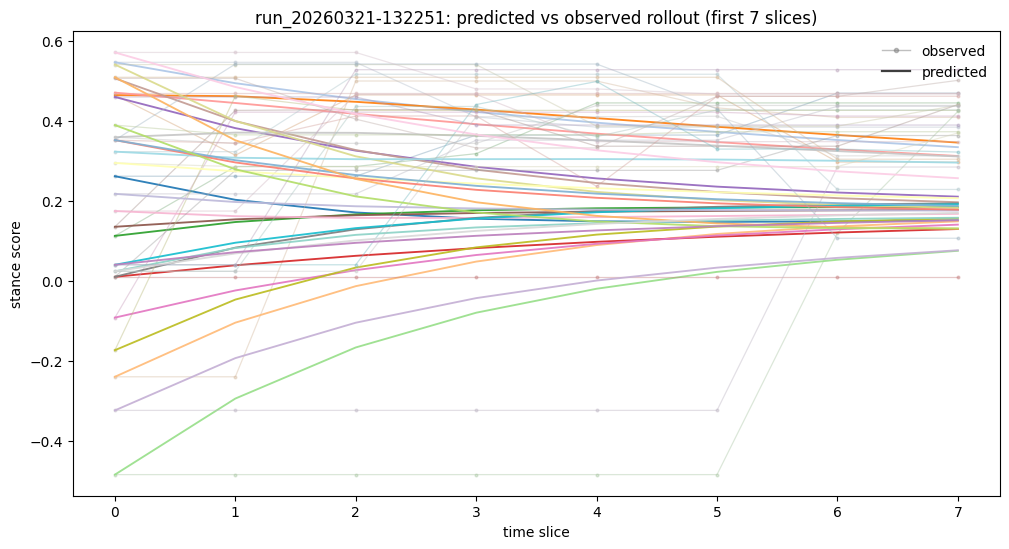

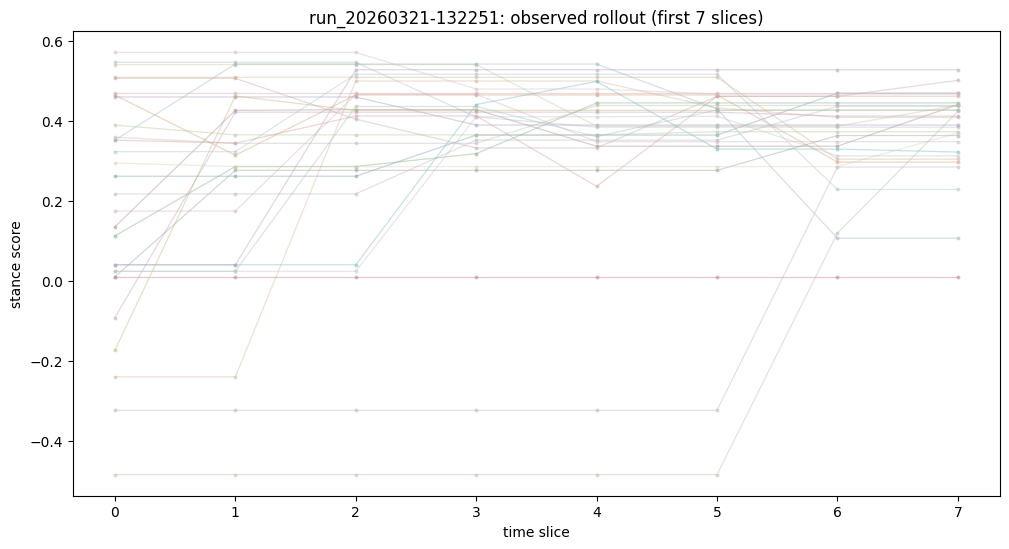

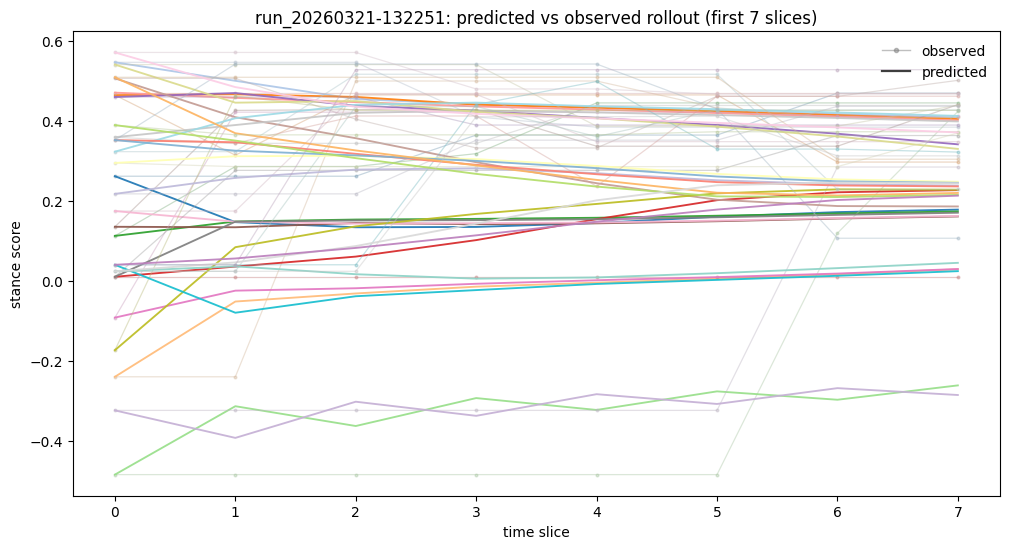

In [9]:
degroot_adj = fit_degroot_adjacency_scalar(RUN_TRAJ, RUN_NEIGHBORS)
GLOBAL_W = degroot_adj['W']
DEGROOT_GAMMA = degroot_adj['gamma']
DEGROOT_POOL_MSE = degroot_adj['mse_pool']

PREDICTED_TRAJ_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A, HOMOPHILY_GAMMA, np.asarray(RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in RUN_TRAJ.keys()
}

TRAIN_DEGROOT = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_HOMO = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A,
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)

TRAIN_CURVE_HORIZON = min(
    TRAIN_DEGROOT['mean_true_stack'].shape[1],
    TRAIN_HOMO['mean_true_stack'].shape[1],
)
print('DeGroot adjacency gamma:', DEGROOT_GAMMA)
print('Training metric horizon (shared):', TRAIN_CURVE_HORIZON)

plot_mean_per_timestep(
    TRAIN_DEGROOT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_DEGROOT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_DEGROOT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

plot_mean_per_timestep(
    TRAIN_HOMO['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

train_summary = pd.DataFrame([
    {
        'model': 'degroot_adjacency_scalar',
        'pooled_mse': DEGROOT_POOL_MSE,
        'transition_mse_mean': TRAIN_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'pooled_mse': HOMOPHILY['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO['wasserstein_curve_mean'],
    },
])
print(train_summary)

run_names = sorted(RUN_TRAJ.keys())
run_id = run_names[12]
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], degroot_rollout_prediction(GLOBAL_W, np.asarray(RUN_TRAJ[run_id], dtype=float)[0], PARAMS['rollout_horizon_cap']), GLOBAL_AGENT_IDS, 10)
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_HOMO[run_id], GLOBAL_AGENT_IDS, 10)

## Validation

In [5]:
TEST_DATA_ROOT = ROOT / 'init_conditions'
TEST_RUN_DIRS = sorted([p for p in TEST_DATA_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {r.name: load_run_data(r) for r in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {rn: tm[0] for rn, tm in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {rn: build_neighbors_index(data, GLOBAL_AGENT_IDS) for rn, data in TEST_RUN_DATA.items()}
TEST_RUN_NAMES = sorted(TEST_RUN_TRAJ.keys())
print('Validation runs found:', len(TEST_RUN_NAMES))

Validation runs found: 8


Validation metric horizon (shared): 5


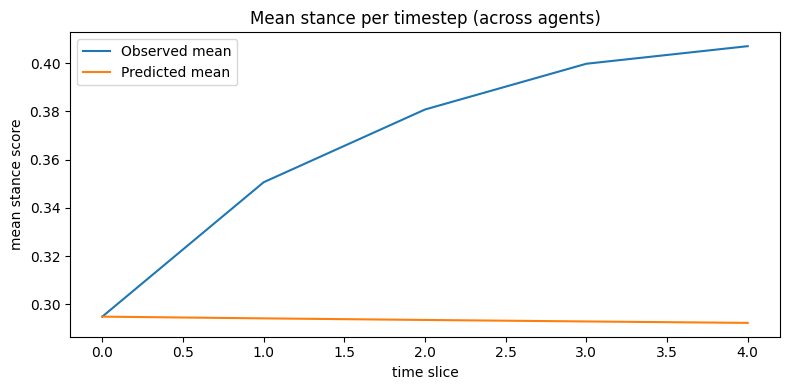

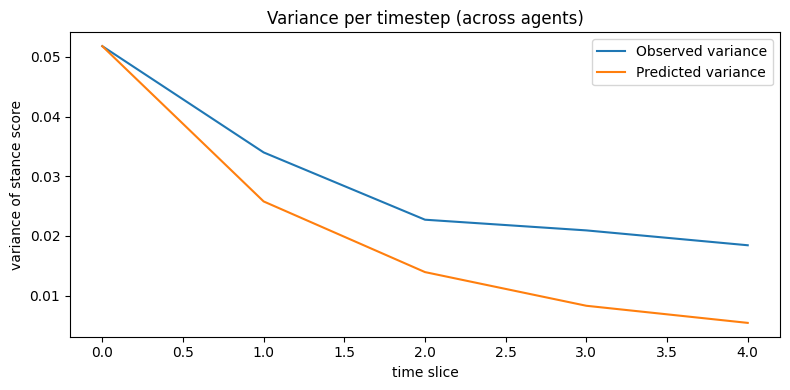

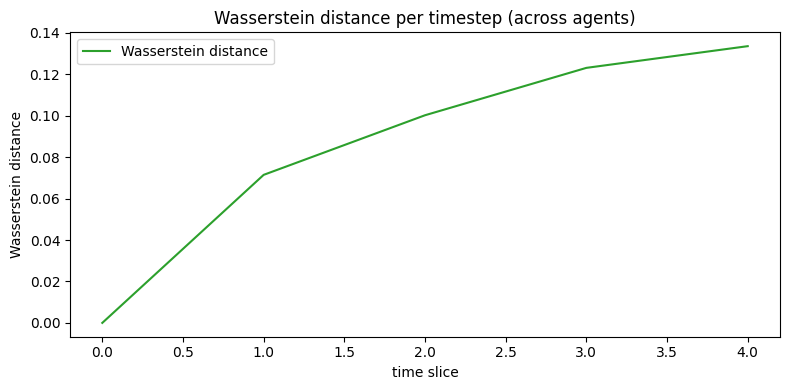

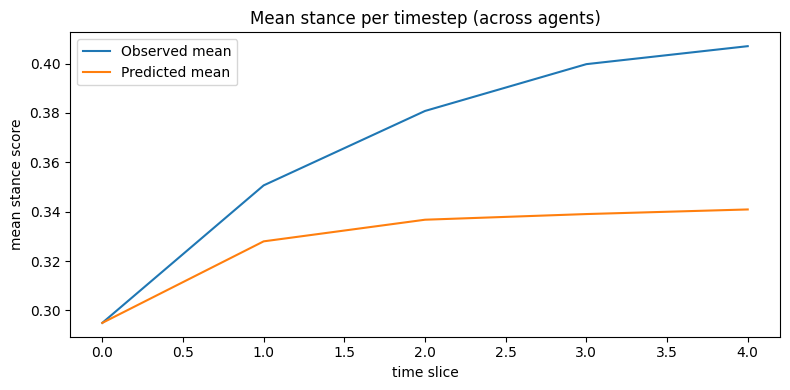

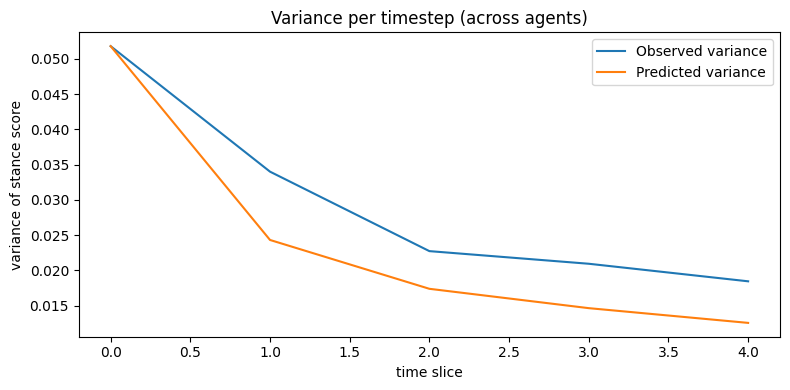

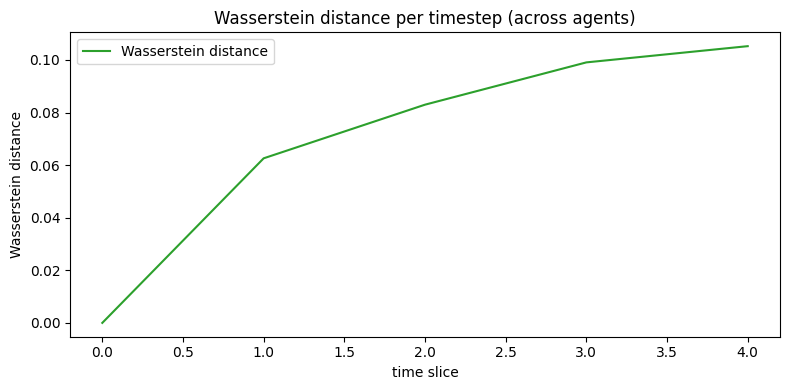

       model  transition_mse_mean  mean_curve_abs_error  var_curve_abs_error  \
0    degroot             0.027616              0.073101             0.009176   
1  homophily             0.029411              0.051852             0.012889   

   wasserstein_curve_mean  
0                0.085706  
1                0.069977  


In [6]:
TEST_DEGROOT = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_HOMO = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A,
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)

VALIDATION_CURVE_HORIZON = min(
    TEST_DEGROOT['mean_true_stack'].shape[1],
    TEST_HOMO['mean_true_stack'].shape[1],
)

print('Validation metric horizon (shared):', VALIDATION_CURVE_HORIZON)

plot_mean_per_timestep(
    TEST_DEGROOT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_DEGROOT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_DEGROOT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

plot_mean_per_timestep(
    TEST_HOMO['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

test_summary = pd.DataFrame([
    {
        'model': 'degroot',
        'transition_mse_mean': TEST_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TEST_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'transition_mse_mean': TEST_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO['wasserstein_curve_mean'],
    },
])
print(test_summary)

Validation sample run: run_20260414-043038
Plot horizon (slices): 9


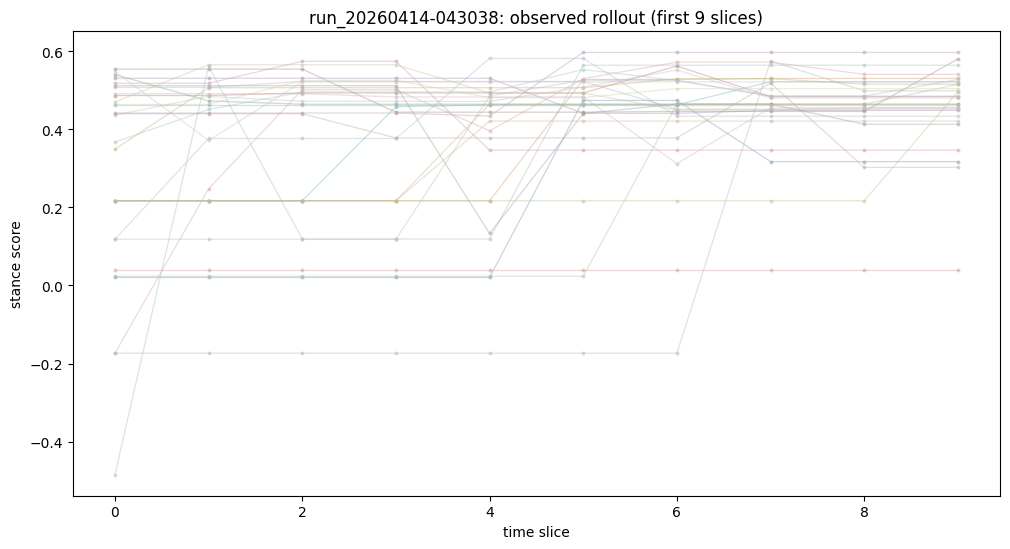

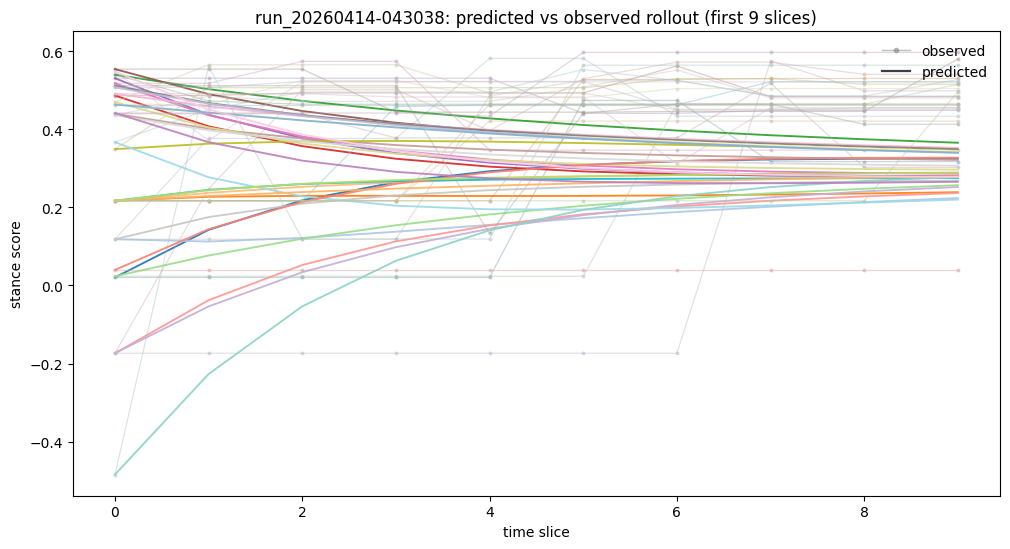

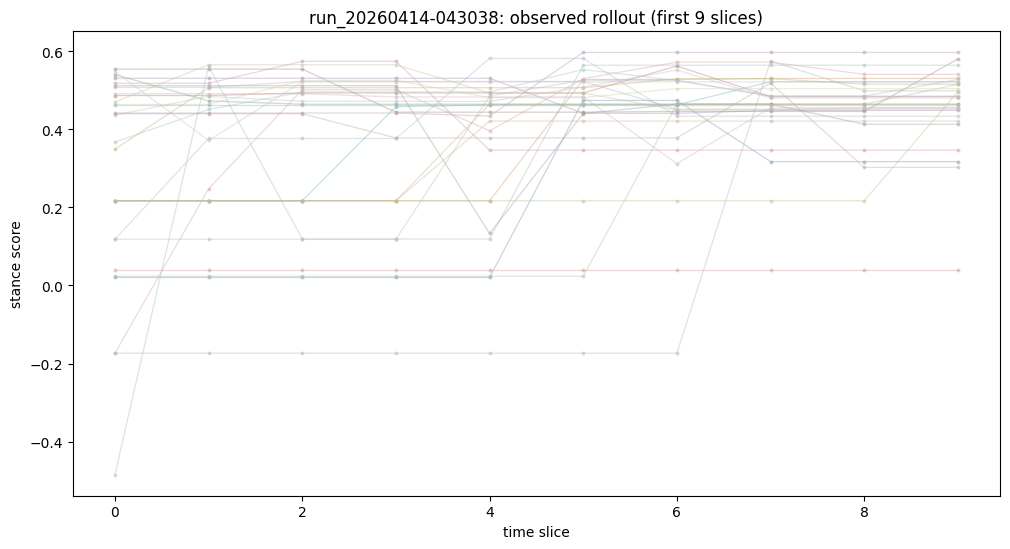

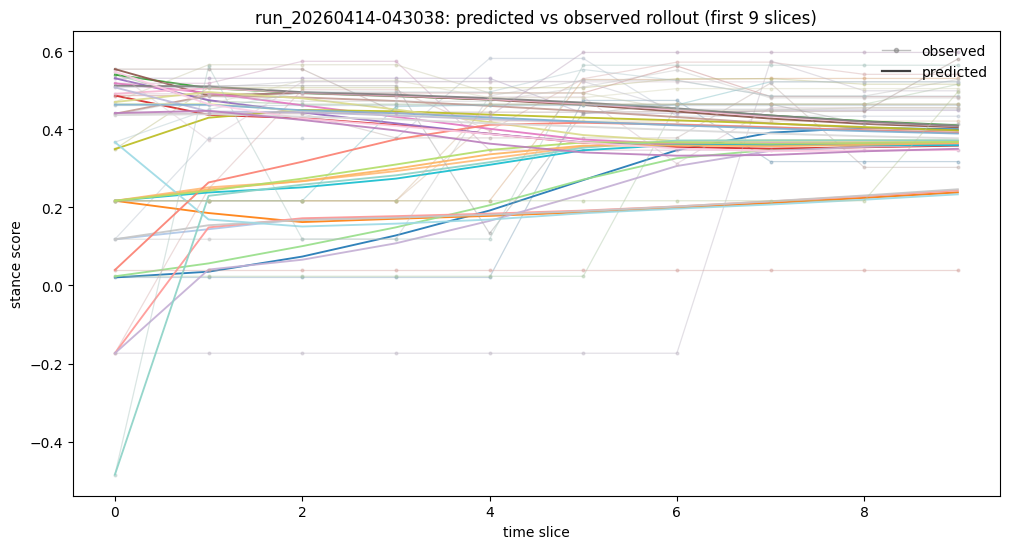

In [7]:
PREDICTED_TEST_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A, HOMOPHILY_GAMMA, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_DEGROOT = {
    rn: degroot_rollout_prediction(GLOBAL_W, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}

run_id = max(TEST_RUN_NAMES, key=lambda rn: np.asarray(TEST_RUN_TRAJ[rn], dtype=float).shape[0])
plot_horizon = min(
    10,
    np.asarray(TEST_RUN_TRAJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_HOMO[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_DEGROOT[run_id], dtype=float).shape[0] - 1,
)

print('Validation sample run:', run_id)
print('Plot horizon (slices):', plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_DEGROOT[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_HOMO[run_id], GLOBAL_AGENT_IDS, plot_horizon)